# AP 155 Lab Exercise
---
## Exercise 4: Derivatives

_Instructions_: 
- **Report figure (See Problem 1):** Plot of mean absolute error vs. step size (spacing between points) when using the forward, backward, and central difference approach to get first derivative
- **Report discussion:** Explain the results of your figure. How do the central and non-central difference formulas arrive at such accuracies? Looking outward, when is each method of differentiation suitable/appropriate? 
  
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Maribao, Jake Agustin
- _Student No._: 2023-08777
- _Section_: THR-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

![Mean absolute error vs step size](fig_mae_vs_h.png)

**Figure 1.** Mean absolute error of the forward, backward and central first-derivative
approximations to $f(x) = 2 + 5x\sin(x + \pi/4)$ on $[0, 4\pi]$, plotted against the step
size $h = 4\pi/2^k$ for $k = 3,\dots,22$ (equivalently $N = 2^k + 1$ points).
Forward and backward errors fall as $h^1$, central as $h^2$,
until floating-point roundoff ($\sim10^{-9}$) takes over below $h \approx 10^{-5}$.

### Report discussion

**Explain the results of your figure.** On log-log axes all three curves are straight
lines over most of the range, so the error scales as a power of $h$ and the slope is the
order of accuracy. Forward and backward sit on top of each other with slope 1: halving
$h$ halves the error (the printed table goes $0.4996 \to 0.2499 \to 0.1250$). Central has
slope 2, halving $h$ quarters the error ($9.65\times10^{-3} \to 2.42\times10^{-3} \to
6.04\times10^{-4}$). On the 257-point grid central is about
50 times more accurate than either one-sided formula from the *same* data, and the gap
keeps widening as $h$ shrinks. Below $h \approx 10^{-5}$ ($N \gtrsim 10^6$) the central
curve flattens near $10^{-9}$ and turns upward: truncation error has dropped below
roundoff. Subtracting two nearly equal function values loses significant digits, and
dividing by a tiny $h$ amplifies the loss roughly as $\varepsilon|f|/h$. The one-sided
formulas never reach that floor in the range shown because their truncation error
($\sim10^{-5}$) is still far above it.

**How do the central and non-central formulas arrive at such accuracies?** Expand
$f(x_i \pm h) = f \pm h f' + \tfrac{h^2}{2} f'' \pm \tfrac{h^3}{6} f''' + \cdots$ around
$x_i$. The forward formula $[f(x_i+h) - f(x_i)]/h$ gives $f' + \tfrac{h}{2}f'' + O(h^2)$.
Backward is the same with the opposite sign, $f' - \tfrac{h}{2}f''$. The central formula 
subtracts $f(x_i - h)$ from $f(x_i + h)$, and in that subtraction *every even power of $h$ 
cancels* including the $\tfrac{h^2}{2}f''$ term leaving $f' + \tfrac{h^2}{6}f''' + O(h^4)$. 
The extra accuracy therefore comes from symmetry, not from using more data. The $+h$ and $-h$
errors are equal and opposite which is also why the central formula is exactly the
average of the forward and backward ones.

**When is each method suitable?** Central is the default whenever data exist on both
sides of the point and the function is smooth such as interior points of a table, spatial
derivatives on a grid, any offline analysis. The one-sided formulas are needed in three
situations. At the domain boundaries a neighbour is missing, so central cannot produce
$f'(x_0)$ or $f'(x_N)$ at all. In time-marching or real-time problems only the past is
available, a controller estimating a rate cannot wait for the next sample, so backward
difference is the only causal choice. And next to a kink or discontinuity a central
stencil straddles the feature and averages across it, whereas a one-sided stencil stays
on one side. Two further practical points follow from the figure. Do not push $h$ toward
zero: the floor shows the best $h$ balances truncation against roundoff (roughly
$\varepsilon^{1/2}$ for one-sided, $\varepsilon^{1/3}$ for central). And with noisy
measured data the same $\varepsilon/h$ amplification acts on the noise, so a coarser step
or prior smoothing beats a finer grid. On uneven spacing the code still works, but the
central formula drops back to first order unless the spacing varies smoothly.

### Other comments
- The bonus item (uneven spacing) is handled by reading $h$ from the `x` array
  rather than assuming a constant step.
- The sweep was extended to $N \approx 4\times10^6$ specifically to reach the roundoff
  floor for the central formula. The one-sided formulas would need $h \sim 10^{-8}$ to
  show the same effect, which is beyond what fits comfortably in memory.


---
## Section 2: Code

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1:

Consider the function:
$$ f(x) = 2 + 5x\sin\left(x + \frac{\pi}{4}\right)$$

Say you start with 257 points from 0 to $4\pi$ 

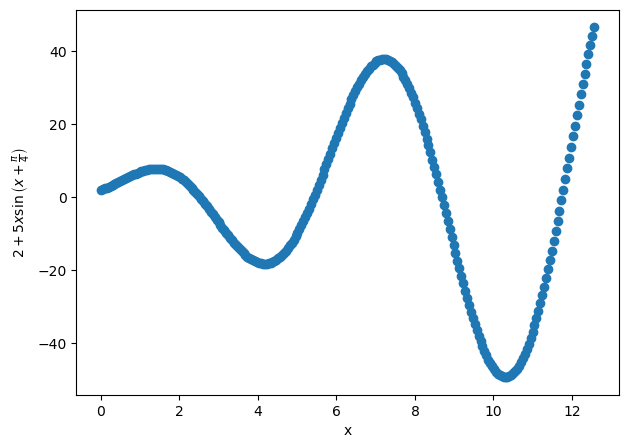

In [8]:
f_0 = lambda x: 2 + 5*x*np.sin(1*x+np.pi/4)
x = np.linspace(0, 4*np.pi, 257)
fig, ax = plt.subplots(figsize = (7,5))
ax.scatter(x, f_0(x))
ax.set_ylabel(r"$2 + 5x\sin\left(x + \frac{\pi}{4}\right)$")
ax.set_xlabel("x")
fig.show()
fig.savefig('f_x.png')

- Create a function that gets the first derivative approximation using the forward, backward, and central difference formulas. (Bonus, not required): Make the function flexible to non-evenly spaced data
- To give yourself a visualization, plot (in a single axis):
  - the three derivative approximations
  - the analytically derived function

- Get the mean absolute error of each of the approximations compared to the analytically derived function
- Repeat the above step for increasing number of points (decreasing spacing) - instead of 256 points, take 512/1024/128/64 points, etc.

- (For the report) Make a plot of the mean absolute error vs the spacing between points. In this plot, there should be three curves: One for the forward, one for the backward, and one for the central difference approximation

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def f_prime_exact(x):
    """Analytic first derivative of f(x) = 2 + 5x sin(x + pi/4)."""
    return 5*np.sin(x + np.pi/4) + 5*x*np.cos(x + np.pi/4)


def first_derivative(x, y, method):
    """First-derivative approximation."""
    d = np.full(len(y), np.nan)
    if method == 'forward':
        d[:-1] = (y[1:] - y[:-1]) / (x[1:] - x[:-1])
    elif method == 'backward':
        d[1:] = (y[1:] - y[:-1]) / (x[1:] - x[:-1])
    elif method == 'central':
        d[1:-1] = (y[2:] - y[:-2]) / (x[2:] - x[:-2])
    else:
        raise ValueError(f"unknown method {method!r}")
    return d


def mean_abs_error(approx, exact):
    """Mean |approx - exact| over the points where approx is defined."""
    return np.nanmean(np.abs(approx - exact))


METHODS = ('forward', 'backward', 'central')
MARKERS = {'forward': 'v', 'backward': '^', 'central': 'o'}

 forward difference, N = 257:  MAE = 4.9955e-01
backward difference, N = 257:  MAE = 5.0053e-01
 central difference, N = 257:  MAE = 9.6522e-03


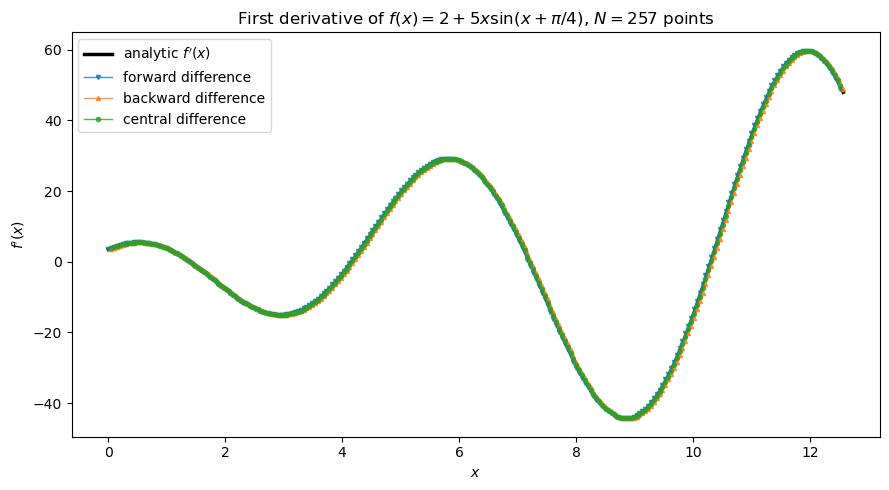

In [10]:
# Visual check on the 257-point grid from the problem statement
# the three approximations against the analytic derivative, on one axis.

x = np.linspace(0, 4*np.pi, 257)
y = f_0(x)
exact = f_prime_exact(x)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, exact, 'k-', lw=2.5, label="analytic $f'(x)$")
for method in METHODS:
    ax.plot(x, first_derivative(x, y, method), lw=1, marker=MARKERS[method],
            ms=3, alpha=0.8, label=f'{method} difference')
ax.set_xlabel('$x$')
ax.set_ylabel("$f'(x)$")
ax.set_title("First derivative of $f(x) = 2 + 5x\\sin(x + \\pi/4)$, $N = 257$ points")
ax.legend()
fig.tight_layout()
plt.savefig('fig_derivative')

for method in METHODS:
    print(f"{method:>8} difference, N = 257:  MAE = "
          f"{mean_abs_error(first_derivative(x, y, method), exact):.4e}")

In [11]:
# Sweep the number of points. N = 2**k + 1 makes h = 4*pi / 2**k, so the step halves cleanly each time (the 257-point grid above is k = 8).
ks = np.arange(3, 23)
h_values = 4*np.pi / 2.0**ks
mae = {method: np.empty(len(ks)) for method in METHODS}

for j, k in enumerate(ks):
    x = np.linspace(0, 4*np.pi, 2**k + 1)
    y, exact = f_0(x), f_prime_exact(x)
    for method in METHODS:
        mae[method][j] = mean_abs_error(first_derivative(x, y, method), exact)

print(f"{'N':>9} {'h':>10} | {'forward':>10} {'backward':>10} {'central':>10}")
for j, k in enumerate(ks):
    print(f"{2**k + 1:>9} {h_values[j]:10.3e} | {mae['forward'][j]:10.3e} "
          f"{mae['backward'][j]:10.3e} {mae['central'][j]:10.3e}")

        N          h |    forward   backward    central
        9  1.571e+00 |  1.490e+01  1.262e+01  8.001e+00
       17  7.854e-01 |  7.507e+00  8.028e+00  2.359e+00
       33  3.927e-01 |  3.935e+00  4.001e+00  6.051e-01
       65  1.963e-01 |  1.992e+00  2.004e+00  1.533e-01
      129  9.817e-02 |  9.977e-01  1.002e+00  3.853e-02
      257  4.909e-02 |  4.996e-01  5.005e-01  9.652e-03
      513  2.454e-02 |  2.499e-01  2.502e-01  2.415e-03
     1025  1.227e-02 |  1.250e-01  1.251e-01  6.040e-04
     2049  6.136e-03 |  6.251e-02  6.252e-02  1.510e-04
     4097  3.068e-03 |  3.125e-02  3.126e-02  3.776e-05
     8193  1.534e-03 |  1.563e-02  1.563e-02  9.441e-06
    16385  7.670e-04 |  7.814e-03  7.814e-03  2.360e-06
    32769  3.835e-04 |  3.907e-03  3.907e-03  5.901e-07
    65537  1.917e-04 |  1.954e-03  1.954e-03  1.475e-07
   131073  9.587e-05 |  9.768e-04  9.768e-04  3.688e-08
   262145  4.794e-05 |  4.884e-04  4.884e-04  9.220e-09
   524289  2.397e-05 |  2.442e-04  2.442e-04  2.

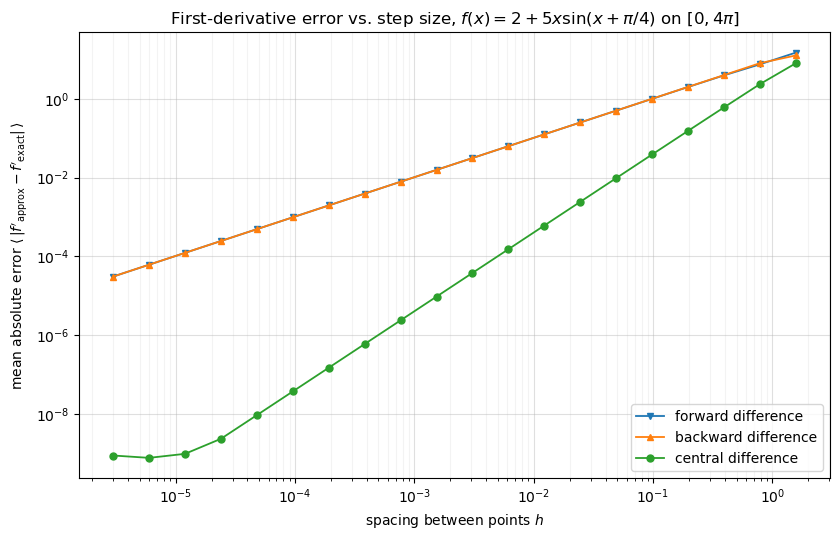

In [12]:
# Report figure.

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for method in METHODS:
    ax.loglog(h_values, mae[method], marker=MARKERS[method], ms=5, lw=1.3,
              label=f'{method} difference')

ax.set_xlabel(r'spacing between points $h$')
ax.set_ylabel(r"mean absolute error $\langle\,|f'_{\mathrm{approx}} - f'_{\mathrm{exact}}|\,\rangle$")
ax.set_title(r"First-derivative error vs. step size, $f(x) = 2 + 5x\sin(x+\pi/4)$ on $[0, 4\pi]$")

ax.grid(True, which='major', alpha=0.4)
ax.grid(True, which='minor', alpha=0.15)
ax.legend(loc='lower right')
fig.tight_layout()

plt.savefig('fig_mae_vs_h.png')

**Problem 1 algorithm notes**

1. **One derivative function, three stencils.** `first_derivative(x, y, method)` builds the
   derivative with NumPy slicing rather than a Python loop which makes `y[1:] - y[:-1]` every
   $f(x_{i+1}) - f(x_i)$ at once. The step $h$ is read from `x` itself
   (`x[1:] - x[:-1]`, or `x[2:] - x[:-2]` for the $2h$ of the central formula), so the
   same code works for unevenly spaced data, the bonus item.
2. **Boundaries are `NaN`, not fudged.** The forward stencil has no $x_{i+1}$ at the last
   point, backward has no $x_{i-1}$ at the first, and central has neither at both ends.
   Those entries are left as `NaN` so every method is judged only where its own formula
   applies, `np.nanmean` then skips them when computing the mean absolute error.
3. **Step-size sweep.** $N = 2^k + 1$ points for $k = 3,\dots,22$ gives
   $h = 4\pi/2^k$, so $h$ halves exactly at every step (the 257-point grid in the problem
   statement is $k=8$). Each $N$ is evaluated once and only the three MAE values are kept,
   so memory stays flat even at $N \approx 4\times10^6$.

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---

**Problem 1 code summary**

The script measures how the error of three finite-difference first-derivative formulas
scales with the step size $h$, using a function whose derivative is known exactly so the
error can be computed rather than estimated. A single vectorised `first_derivative`
function implements all three stencils through NumPy slicing, reads $h$ from the `x`
array (so it also handles uneven spacing), and marks undefined boundary points as `NaN`
so each method is scored only where its formula is valid. The sweep uses $N = 2^k + 1$
so that $h$ halves exactly between runs, which makes the slopes on the log-log report
figure read off directly as the order of accuracy.

## Section 3 (Notes)

### Non-central difference formulas (First Derivative)

* Forward 
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{x})}{h} + O(h)
$$

* Backward
$$
f'(x_i) = \frac{f(x_{i}) - f(x_{i-1})}{h} + O(h)
$$



### Central-difference formulas

* First Derivative
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{i-1})}{2h} + O(h^2)
$$

* Second Derivative
$$
f''(x_i) = \frac{f(x_{i+1}) - 2f(x_{i}) + f(x_{i-1})}{h^2} + O(h^2)
$$

Note: to avoid confusion, think: $x_i$ is `x[i]`, and $h$ is the gap between `x[i+1]` and `x[i]`.


In [7]:
## Useful tips. Not required to solve the problems below!

# Suppose you have a Numpy array
x = np.linspace(1, 10, 10)
print(x)

# I can move all values to the left/right using roll
x_roll = np.roll(x, 1) # change 1 to -1, what happens? 
x_roll2 = np.roll(x, -1)
print(x_roll)

# then I could exploit array operations to get their difference
x_diff = (x_roll - x)[1:]
print(x_diff)
# Be careful with the boundaries!

x_diff2 = (x_roll2 - x_roll)[:]
print(x_diff2)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
[10.  1.  2.  3.  4.  5.  6.  7.  8.  9.]
[-1. -1. -1. -1. -1. -1. -1. -1. -1.]
[-8.  2.  2.  2.  2.  2.  2.  2.  2. -8.]
